In [1]:
import pandas as pd
import os

file_name = "processed_ar.csv"
data_path = os.path.join('../datasets/processed/', file_name)

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()
df.head()

,countryCode,customerID,invoiceNumber,InvoiceAmount,PaperlessBill,CreditTermDays,InvoiceMonth,InvoiceDayOfWeek,InvoiceQuarter,DaysSincePaperless,CustomerFreq,target
0,391,6708-DPYTF,5133177585,55.37,Paper,30,1,1,1,0,0,0
1,770,3993-QUNVJ,280670965,50.39,Paper,30,1,1,1,0,0,0
2,406,5164-VMYWJ,6393629835,71.33,Paper,30,1,1,1,0,0,0
3,818,1604-LIFKX,5928070131,97.60,Paper,30,1,1,1,0,0,0
4,818,8887-NCUZC,6050714721,15.99,Paper,30,1,1,1,0,0,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

CATEGORICAL = ['countryCode', 'PaperlessBill']
NUMERIC     = ['InvoiceAmount', 'CreditTermDays', 'InvoiceMonth',
                'InvoiceDayOfWeek', 'InvoiceQuarter', 'DaysSincePaperless', 'CustomerFreq']

X = df[CATEGORICAL + NUMERIC].copy()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessor shared by both baseline models
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
        ('num', StandardScaler(), NUMERIC),
    ]
)

# Preprocessor without scaling (for Random Forest)
preprocess_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ],
    remainder='passthrough'
)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print('Dispute rate in train:', y_train.mean().round(3),
      '| test:', y_test.mean().round(3))

Train size: (1972, 9) | Test size: (494, 9)
Dispute rate in train: 0.228 | test: 0.227


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

lr.fit(X_train, y_train)
y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

=== Logistic Regression (Baseline) ===
Accuracy : 0.6518
Precision: 0.3544
Recall   : 0.6518
F1       : 0.4591
ROC-AUC  : 0.6931

              precision    recall  f1-score   support

          No       0.86      0.65      0.74       382
         Yes       0.35      0.65      0.46       112

    accuracy                           0.65       494
   macro avg       0.61      0.65      0.60       494
weighted avg       0.75      0.65      0.68       494



In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ('preprocess', preprocess_rf),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),
])

rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest (Baseline) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

=== Random Forest (Baseline) ===
Accuracy : 0.7571
Precision: 0.4130
Recall   : 0.1696
F1       : 0.2405
ROC-AUC  : 0.6362

              precision    recall  f1-score   support

          No       0.79      0.93      0.86       382
         Yes       0.41      0.17      0.24       112

    accuracy                           0.76       494
   macro avg       0.60      0.55      0.55       494
weighted avg       0.71      0.76      0.72       494



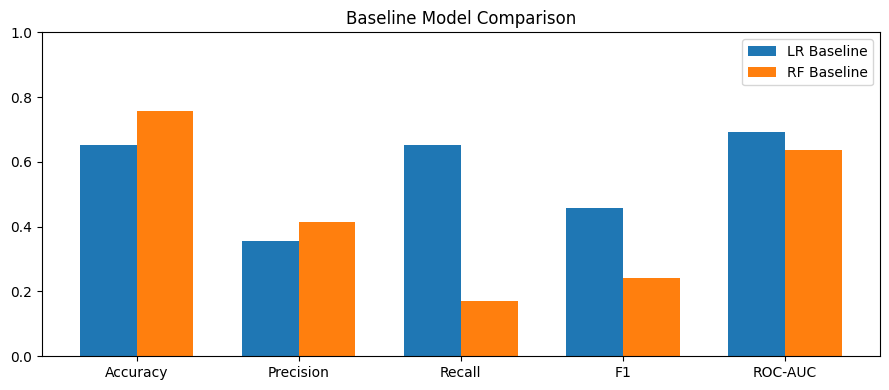

In [5]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_prob_lr),
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf),
]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, lr_scores, width, label='LR Baseline')
ax.bar(x + width/2, rf_scores, width, label='RF Baseline')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Baseline Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()